In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import pickle
import re
import matplotlib.pyplot as plt

# Fungsi untuk membersihkan teks
def clean_text(text):
    text = str(text).lower() # Mengubah ke huruf kecil
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # Menghapus tanda baca
    return text

# Load Data
file_path = 'DataChat.csv'
df = pd.read_csv(file_path)

print("Data Awal:")
print(df.head())

# Pra-pemrosesan data
df['text'] = df['text'].apply(clean_text)

# Hapus duplikat dan data kosong
df_intent = df.drop_duplicates(subset='text').dropna(subset=['intent'])
print("\nData setelah dibersihkan dan duplikat dihapus:")
print(df_intent.head())
print(f"Total data unik: {len(df_intent)}")

Data Awal:
                                                text      intent entity_name  \
0  Saya ingin mengetahui jadwal kunjungan hari Se...  cek_jadwal        hari   
1                  Apakah hari Selasa ada kunjungan?  cek_jadwal        hari   
2              Jadwal kunjungan hari Rabu bagaimana?  cek_jadwal        hari   
3                   Apakah hari Kamis bisa membesuk?  cek_jadwal        hari   
4           Apakah hari Jumat ada layanan kunjungan?  cek_jadwal        hari   

  entity_value  
0       Selasa  
1       Selasa  
2         Rabu  
3        Kamis  
4        Jumat  

Data setelah dibersihkan dan duplikat dihapus:
                                                text      intent entity_name  \
0  saya ingin mengetahui jadwal kunjungan hari se...  cek_jadwal        hari   
1                   apakah hari selasa ada kunjungan  cek_jadwal        hari   
2               jadwal kunjungan hari rabu bagaimana  cek_jadwal        hari   
3                    apakah hari kamis

In [12]:
# Tokenisasi dan Padding
texts = df_intent['text'].values
intents = df_intent['intent'].values

tokenizer = Tokenizer(num_words=2000, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

max_length = 20
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

# Label Encoding
label_encoder = LabelEncoder()
encoded_intents = label_encoder.fit_transform(intents)
num_classes = len(label_encoder.classes_)

print(f"Total kelas: {num_classes}")
print(f"Daftar intent: {label_encoder.classes_}")

Total kelas: 14
Daftar intent: ['barang_bawaan' 'barang_boleh' 'barang_terlarang' 'cara_pendaftaran'
 'cek_jadwal' 'durasi_kunjungan' 'fasilitas' 'ketentuan_pakaian'
 'ketentuan_pengunjung' 'kontak' 'lokasi_layanan' 'penutup' 'sapaan'
 'syarat_kunjungan']


In [13]:
# Arsitektur Model LSTM
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(2000, 64, input_length=max_length),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 20, 64)            128000    
                                                                 
 lstm_2 (LSTM)               (None, 20, 64)            33024     
                                                                 
 global_max_pooling1d_2 (Glo  (None, 64)               0         
 balMaxPooling1D)                                                
                                                                 
 dense_4 (Dense)             (None, 64)                4160      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 14)                910       
                                                      

In [14]:
# Pelatihan Model
epochs = 200
history = model.fit(
    padded_sequences, 
    encoded_intents, 
    epochs=epochs, 
    verbose=1
)
print("Model selesai dilatih.")

Epoch 1/200
5/5 [==============================] - 4s 20ms/step - loss: 2.6339 - accuracy: 0.0872
Epoch 2/200
5/5 [==============================] - 0s 18ms/step - loss: 2.6177 - accuracy: 0.1544
Epoch 3/200
5/5 [==============================] - 0s 17ms/step - loss: 2.5958 - accuracy: 0.1678
Epoch 4/200
5/5 [==============================] - 0s 17ms/step - loss: 2.5463 - accuracy: 0.1611
Epoch 5/200
5/5 [==============================] - 0s 17ms/step - loss: 2.5067 - accuracy: 0.1812
Epoch 6/200
5/5 [==============================] - 0s 17ms/step - loss: 2.4845 - accuracy: 0.1477
Epoch 7/200
5/5 [==============================] - 0s 17ms/step - loss: 2.4495 - accuracy: 0.1812
Epoch 8/200
5/5 [==============================] - 0s 17ms/step - loss: 2.4430 - accuracy: 0.1879
Epoch 9/200
5/5 [==============================] - 0s 17ms/step - loss: 2.4021 - accuracy: 0.2282
Epoch 10/200
5/5 [==============================] - 0s 18ms/step - loss: 2.3704 - accuracy: 0.2081
Epoch 11/200
5/5 [=

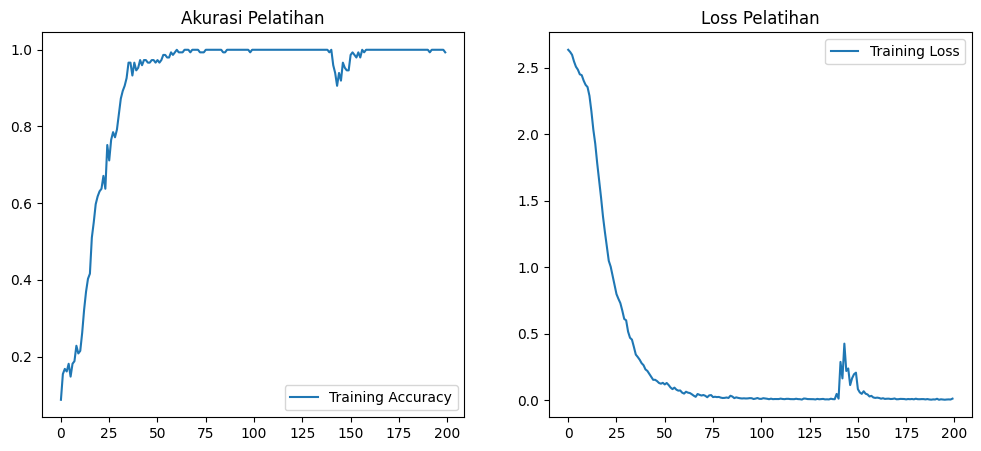

In [15]:
# Visualisasi Hasil Pelatihan
acc = history.history['accuracy']
loss = history.history['loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.title('Akurasi Pelatihan')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.title('Loss Pelatihan')
plt.legend()
plt.show()

In [16]:
# Menyimpan Model dan Artefak menggunakan Pickle
with open('model_chatbot.pickle', 'wb') as handle:
    pickle.dump(model, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Model dan artefak (tokenizer, label_encoder) berhasil disimpan dalam format pickle.")

Model dan artefak (tokenizer, label_encoder) berhasil disimpan dalam format pickle.


In [1]:
import pandas as pd
import numpy as np
import random
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================
# LOAD CSV DATA
# =========================
df_response = pd.read_csv("DataResponse.csv")
df_barang = pd.read_csv("DataBarang.csv")
df_jadwal = pd.read_csv("DataJadwal.csv")
df_fasilitas = pd.read_csv("DataFasilitas.csv")


# =========================
# PREDICT INTENT
# =========================
def predict_intent(text, threshold=0.65):
    cleaned_text = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    if not sequence or not sequence[0]:
        return "unknown", 0.0

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    prediction = model.predict(padded, verbose=0)[0]

    class_index = np.argmax(prediction)
    confidence = float(prediction[class_index])

    if confidence < threshold:
        return "fallback", confidence

    intent = label_encoder.classes_[class_index]

    return intent, confidence


# =========================
# GET RESPONSE
# =========================
def get_response(intent, user_input):
    text = user_input.lower().strip()

    # =========================
    # CEK DATA BARANG
    # =========================
    if intent in ["barang_terlarang", "barang_bawaan"]:
        for _, row in df_barang.iterrows():
            nama_barang = str(row["nama_barang"]).lower()

            if nama_barang in text or any(
                kata in text for kata in nama_barang.split()
            ):
                return (
                    f"Mohon maaf, {row['nama_barang']} "
                    f"{row['status']} dibawa masuk. "
                    f"{row['keterangan']}."
                )

    # =========================
    # CEK DATA JADWAL
    # =========================
    if intent == "cek_jadwal":
        for _, row in df_jadwal.iterrows():
            hari = str(row["hari"]).lower()

            if hari in text:
                if str(row["status"]).lower() == "buka":
                    responses = df_response[
                        (df_response["intent"] == "cek_jadwal") &
                        (df_response["keyword"] == "buka")
                    ]["jawaban"].iloc[0].split("|")

                    template = random.choice(responses)

                    return template.format(
                        hari=row["hari"],
                        jam_mulai=row["jam_mulai"],
                        jam_selesai=row["jam_selesai"]
                    )

                else:
                    responses = df_response[
                        (df_response["intent"] == "cek_jadwal") &
                        (df_response["keyword"] == "tutup")
                    ]["jawaban"].iloc[0].split("|")

                    template = random.choice(responses)

                    return template.format(
                        hari=row["hari"]
                    )

    # =========================
    # CEK DATA FASILITAS
    # =========================
    if intent == "fasilitas":
        for _, row in df_fasilitas.iterrows():
            fasilitas = str(row["nama_fasilitas"]).lower()

            if fasilitas in text or any(
                kata in text for kata in fasilitas.split()
            ):
                return (
                    f"{row['nama_fasilitas']} berada di "
                    f"{row['lokasi']}. "
                    f"{row['keterangan']}."
                )

    # =========================
    # TEMPLATE DARI RESPONSE CSV
    # =========================
    rows = df_response[df_response["intent"] == intent]

    if rows.empty:
        return (
            "Mohon maaf, saya belum memahami pertanyaan Anda. "
            "Silakan gunakan menu yang tersedia."
        )

    selected_row = None

    for _, row in rows.iterrows():
        keyword = str(row["keyword"]).lower()

        if keyword != "default" and keyword in text:
            selected_row = row
            break

    if selected_row is None:
        default_rows = rows[
            rows["keyword"].str.lower() == "default"
        ]

        if not default_rows.empty:
            selected_row = default_rows.iloc[0]
        else:
            selected_row = rows.iloc[0]

    responses = selected_row["jawaban"].split("|")

    return random.choice(responses)


# =========================
# TEST INTERAKTIF (STABIL)
# =========================
print("=" * 60)
print("         PAS-Assistant Interactive Testing")
print("Ketik 'exit', 'quit', 'keluar', atau kosong")
print("=" * 60)

try:
    while True:
        try:
            user_input = input("\nMasukkan Pertanyaan: ")

            # Antisipasi input None / kosong
            if user_input is None:
                continue

            user_input = user_input.strip()

            # Exit condition
            if user_input.lower() in ["exit", "quit", "keluar", "stop", ""]:
                print("Chatbot dihentikan.")
                break

            # Prediksi
            intent, confidence = predict_intent(user_input)
            response = get_response(intent, user_input)

            # Output lebih rapi
            print("\n" + "-" * 60)
            print(f"Input      : {user_input}")
            print(f"Intent     : {intent}")
            print(f"Confidence : {confidence:.2%}")
            print(f"Respon     : {response}")
            print("-" * 60)

        except Exception as e:
            print(f"Terjadi error: {e}")
            print("Silakan coba pertanyaan lain.")

except KeyboardInterrupt:
    print("\nTes dihentikan oleh user.")

         PAS-Assistant Interactive Testing
Ketik 'exit', 'quit', 'keluar', atau kosong
Terjadi error: name 'clean_text' is not defined
Silakan coba pertanyaan lain.
Chatbot dihentikan.
